# freeCAM PI-atm

This notebook follows the same object-oriented UI as FreeCESM. Machine paths, run-directory preparation, PBS submission, `mpiexec`, and the persistent socket are implementation details hidden by `freecam.Driver`.

In [1]:
%load_ext autoreload
%autoreload 2

import freecam as fc
import numpy as np

## 1. Create one model

Constructing the driver is cheap and does not submit a job. `PI-atm` uses the original CESM surface components and coupler online by default, so the Notebook does not create or pass a boundary provider. A `CaseConfig` can declare a custom atmosphere workflow before MPI starts. Its factory receives the complete validated default order, so it only needs to describe the changes. Here the same Python physics class is inserted twice; freeCAM creates two independent runtime process instances.

In [2]:
class VolcanicAerosol(fc.Physics):
    name = 'volcanic_aerosol'

    def run(self, state, context):
        # Deliberately visible demonstration cooling: 0.18 K per call at dt=1800 s.
        state.T -= 1.0e-4 * context.timestep_seconds


def volcanic_workflow(default):
    workflow = default.copy()
    workflow.insert_after('dry_adjustment', VolcanicAerosol())
    workflow.insert_before('radiation_tend', VolcanicAerosol())
    return workflow


volcanic_case = fc.CaseConfig(
    name='PI-atm-volcanic',
    description='PI-atm with two Python aerosol tendencies',
    forcing='1850 prescribed SST and sea ice plus volcanic aerosol',
    make_atm=lambda: fc.FreeCAM(workflow=volcanic_workflow),
)

driver = fc.Driver(
    case=volcanic_case,
    nsteps=2,
    history_every=1,
    restart_every='end',
)

comparison_steps = 2 * driver.nsteps
control_driver = fc.Driver(
    case='PI-atm',
    nsteps=comparison_steps,
    history_every=None,
    restart_every=None,
)

### Start the persistent model

Start the volcanic model used by the main Notebook. The control driver is already defined above, but it is initialized later only after volcanic closes: Derecho cpudev permits one 256-CPU PI-CAM model per user at a time.

In [3]:
driver.close()  # Close a previous model if this cell is rerun.
driver.initialize()
display({
    'PI-atm-volcanic': {
        'persistent_job': driver.status.get('job_id', 'managed by Driver'),
        'run_directory': driver.run_dir,
    },
})

PI-CAM Notebook worker submitted as 7112943.desched1; waiting for 512 ranks ...


{'PI-atm-volcanic': {'persistent_job': 'managed by Driver',
  'run_directory': PosixPath('/glade/derecho/scratch/ruitong/freeCAM/PI-cam/notebook-20260813-192629-81db0e11/run')}}

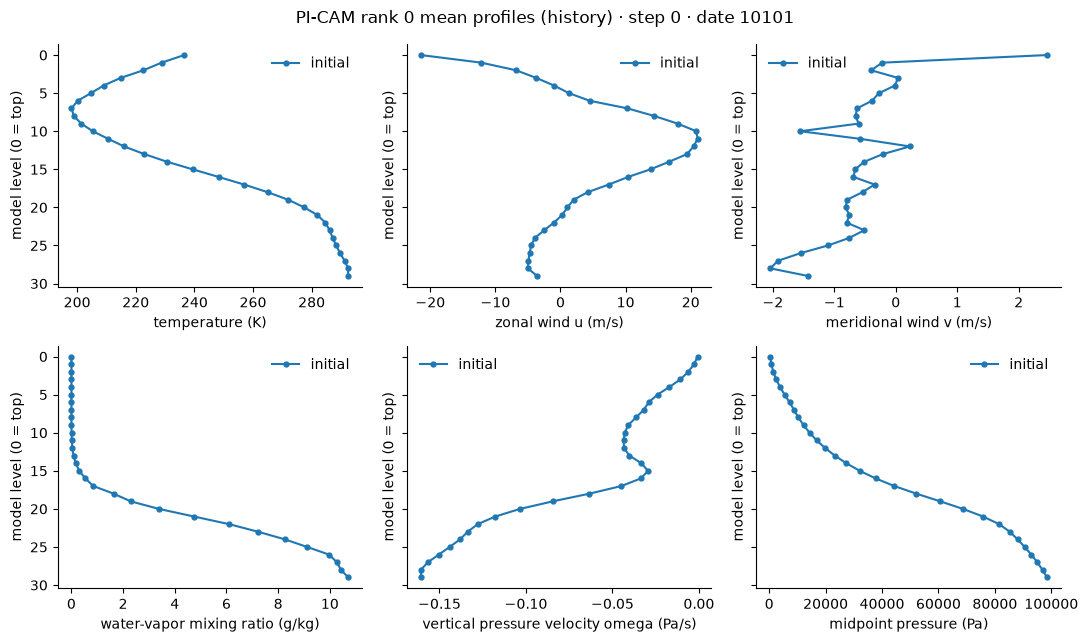

In [4]:
plot_variables = (
    'T', 'u', 'v', 'q',
    'omega', 'pmid',  # unique StatePool leaf names become safe shortcuts
)
profiles = driver.cam.state.plot(
    rank=0, variables=plot_variables, figsize=(11, 6.5),
    mode='history', label='initial',
)
fig, axes = profiles  # optional direct Matplotlib access
# initial_profiles = {
#     variable: np.asarray(axis.lines[-1].get_xdata()).copy()
#     for axis, variable in zip(axes.flat, plot_variables)
# }
display(profiles)

## 2. Inspect and run the Python-owned workflow

The default workflow view is the scientific-process order, written as one explicit Python list just like FreeCESM. Assigning the list atomically reorders those scientific slots on every MPI rank while required control, clock, boundary, and I/O actions keep their source positions. `state.plot_steps(...)` samples a live StatePool diagnostic after every complete step. Use `workflow.debug` only when diagnosing the complete internal order.

CAM step 2/2 (model step 2, date 10101)
step   0  coupling.boundary_import
step   0  cam_run2.prepare
step   0  cam_run2.surface_fluxes_and_emissions
step   0  cam_run2.tracer_tendencies_leaf
step   0  cam_run2.age_of_air_tendencies_leaf
step   0  cam_run2.chemistry_tendencies_leaf
step   0  cam_run2.vertical_diffusion
step   0  cam_run2.rayleigh_friction
step   0  cam_run2.aerosol_dry_deposition_leaf
step   0  cam_run2.carma_aerosol_tendencies_leaf
step   0  cam_run2.charge_neutrality
step   0  cam_run2.gravity_wave_drag
step   0  cam_run2.qbo_relaxation
step   0  cam_run2.ion_drag
step   0  cam_run2.state_finalize
step   0  cam_run2.carma_statistics_leaf
step   0  cam_run2.physics_buffer_deallocate_leaf
step   0  cam_run2.physics_buffer_time_advance_leaf
step   0  cam_run2.diagnostics_deallocate_leaf
step   0  cam_run2.physics_to_dynamics
step   0  cam_run3.dynamics
step   0  cam_run4.history
step   0  cam_run4.restart
step   0  cam_run4.wrapup_leaf
step   0  cam_run4.step_cost_leaf


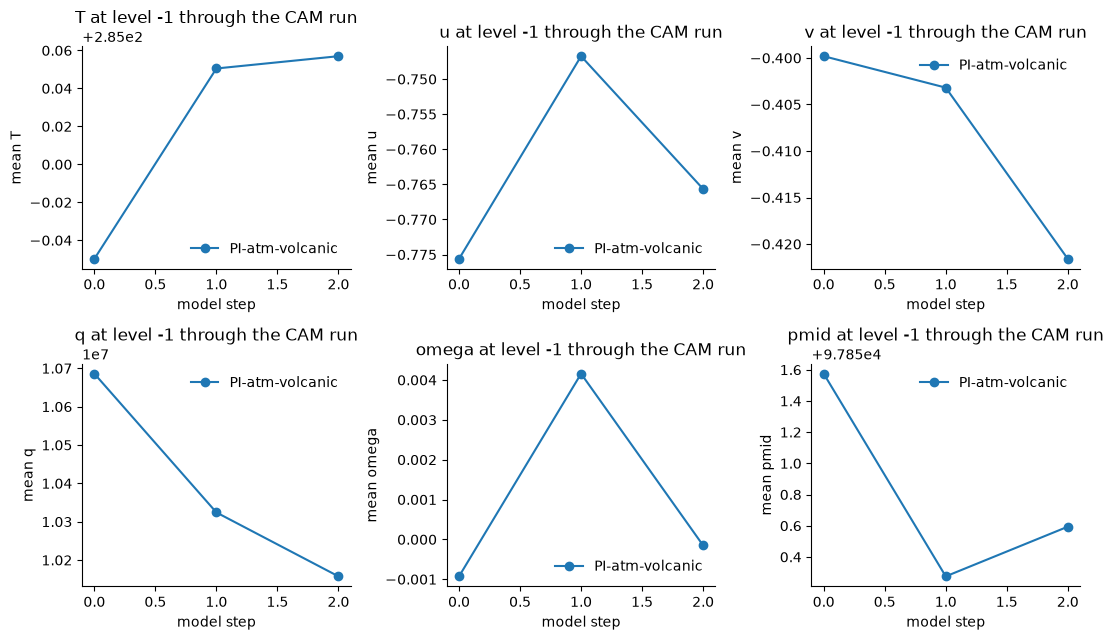

CAM step 2/2 (model step 4, date 10101)
step   2  coupling.boundary_import
step   2  cam_run2.prepare
step   2  cam_run2.surface_fluxes_and_emissions
step   2  cam_run2.tracer_tendencies_leaf
step   2  cam_run2.age_of_air_tendencies_leaf
step   2  cam_run2.chemistry_tendencies_leaf
step   2  cam_run2.vertical_diffusion
step   2  cam_run2.rayleigh_friction
step   2  cam_run2.aerosol_dry_deposition_leaf
step   2  cam_run2.carma_aerosol_tendencies_leaf
step   2  cam_run2.charge_neutrality
step   2  cam_run2.gravity_wave_drag
step   2  cam_run2.qbo_relaxation
step   2  cam_run2.ion_drag
step   2  cam_run2.state_finalize
step   2  cam_run2.carma_statistics_leaf
step   2  cam_run2.physics_buffer_deallocate_leaf
step   2  cam_run2.physics_buffer_time_advance_leaf
step   2  cam_run2.diagnostics_deallocate_leaf
step   2  cam_run2.physics_to_dynamics
step   2  cam_run3.dynamics
step   2  cam_run4.history
step   2  cam_run4.restart
step   2  cam_run4.wrapup_leaf
step   2  cam_run4.step_cost_leaf


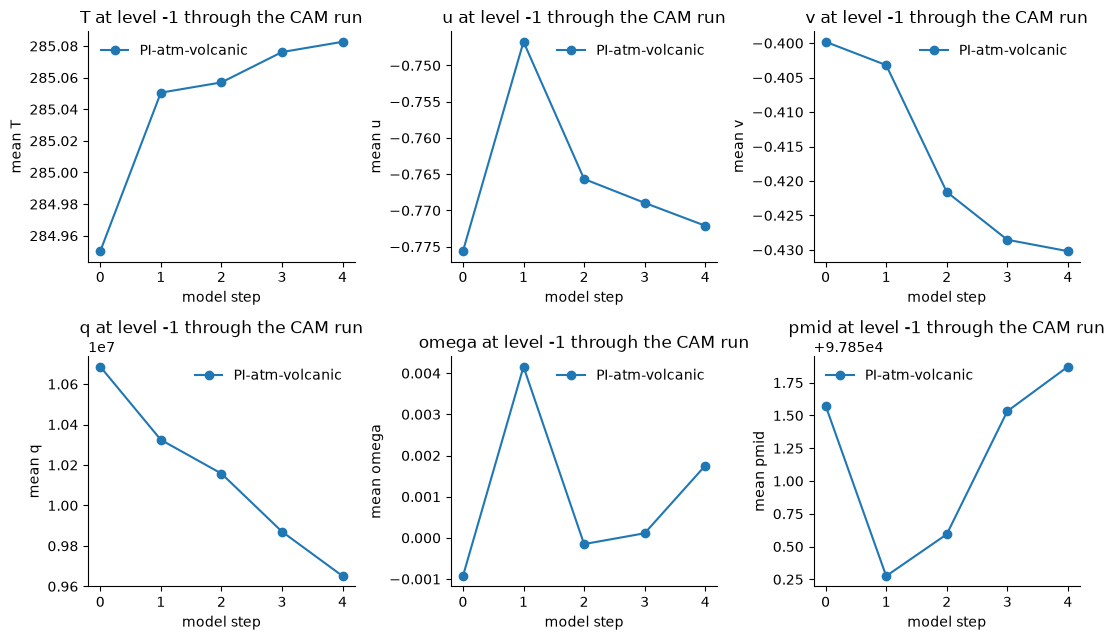

In [5]:
# Capture the current lowest-level global-mean temperature, then sample it
# automatically after every complete model step.
temperature_steps = driver.cam.state.plot_steps(
    plot_variables, rank='global', statistic='mean', level=-1,
    figsize=(11, 6.5), label='PI-atm-volcanic',
)
result = driver.run(progress=True, verbose=True, steps=driver.nsteps)
display(temperature_steps)
result = driver.run(progress=True, verbose=True, steps=driver.nsteps)
display(temperature_steps)

PI-CAM Notebook worker submitted as 7112966.desched1; waiting for 512 ranks ...
CAM step 4/4 (model step 4, date 10101)


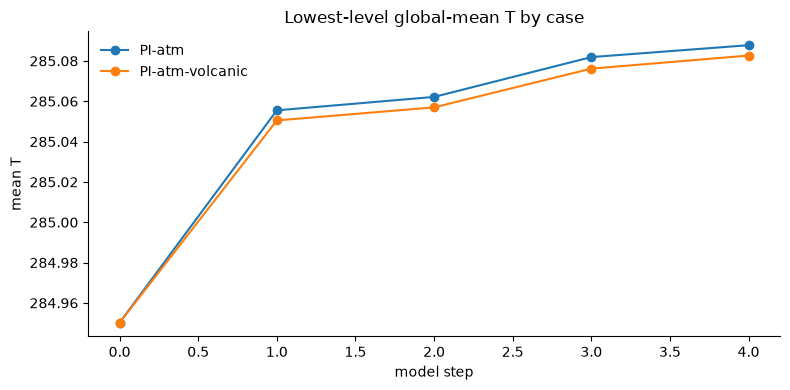

PI-CAM Notebook worker submitted as 7112969.desched1; waiting for 512 ranks ...


In [6]:
# Add a separate same-variable comparison without replacing the six-variable plot.
# cpudev permits only one full PI-CAM allocation per user. Release volcanic,
# run control with the same resources, then restore volcanic for later cells.
driver.close()
try:
    control_driver.initialize()
    control_temperature = control_driver.cam.state.plot_steps(
        'T', rank='global', statistic='mean', level=-1, label='PI-atm',
    )
    control_driver.run(steps=comparison_steps, progress=True)
finally:
    control_driver.close()

temperature_comparison = fc.plot_steps(
    {
        'PI-atm': control_temperature,
        'PI-atm-volcanic': temperature_steps['T'],
    },
    figsize=(8, 4),
    title='Lowest-level global-mean T by case',
)
display(temperature_comparison)

driver.initialize()  # Restore the volcanic model for the following sections.

In [ ]:
# # The default view contains scientific processes only. CAM control, clock,
# # boundary, and I/O actions remain active and are available under .debug.
# workflow = driver.cam.workflow
# source_order = workflow[:]

# # Reordering uses ordinary Python list operations.
# radiation = workflow['radiation']
# vertical_diffusion = workflow['vertical_diffusion']
# custom_order = source_order.copy()
# custom_order.remove(radiation)
# custom_order.insert(custom_order.index(vertical_diffusion), radiation)
# workflow[:] = custom_order

# display(workflow)
# workflow[:] = source_order  # restore the validated PI-CAM order before running

## 3. Add a variable and a Python physics process

Use an ordinary NumPy array for small rank-independent state. For a distributed field, `state.create(..., like='T')` reuses `T`'s rank-local layout. NumPy expressions are evaluated on every rank. A `Physics` object can be inserted directly; simple `state.field` reads and writes are inferred automatically. Dynamic fields can also be monitored with `state.plot_steps(...)`.

In [7]:
NLEV = driver.cam.state.T.metadata['shape'][1]
# - shape[0]: Maximum number of horizontal columns per chunk (pcols)
# - shape[1]: Number of vertical levels (pver)
# - shape[2]: Number of chunks owned by the current MPI rank
driver.cam.state.rh = np.zeros(NLEV)  # same 1-D profile on every rank

driver.cam.state.create('tracer', like='T', units='kg kg-1')

class NotebookTracer(fc.Physics):
    name = 'notebook_tracer_source'
    after = "dry_adjustment"
    def run(self, state, context):
        state.tracer += 1.0e-6 * context.timestep_seconds

# insert() changes the list and returns None, just like list.insert().
driver.cam.workflow.insert(NotebookTracer())
tracer_process = driver.cam.workflow['notebook_tracer_source']
driver.cam.state.T[:, 0, :] += 0.0  # collective no-op slice edit
driver.cam.state.rh = np.clip(driver.cam.state.rh + 0.05, 0.0, 1.0)
driver.cam.state.tracer = np.sin(driver.cam.state.tracer)
driver.cam.workflow

#,process,implementation
0,surface_fluxes_and_emissions,fortran-numerical-kernel
1,tracers_and_chemistry,fortran-numerical-kernel
2,tracer_tendencies,fortran-numerical-kernel
3,age_of_air_tendencies,fortran-numerical-kernel
4,chemistry_tendencies,fortran-numerical-kernel
5,vertical_diffusion,fortran-numerical-kernel
6,rayleigh_friction,fortran-numerical-kernel
7,aerosol_dry_deposition,fortran-numerical-kernel
8,aerosol_dry_deposition,fortran-numerical-kernel
9,carma_aerosol_tendencies,fortran-numerical-kernel


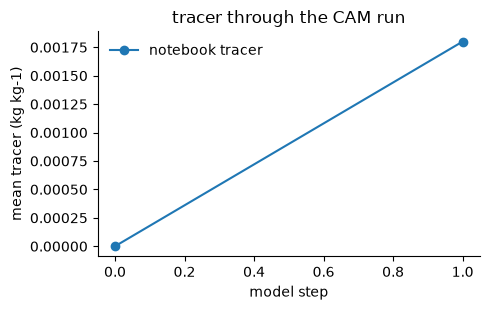

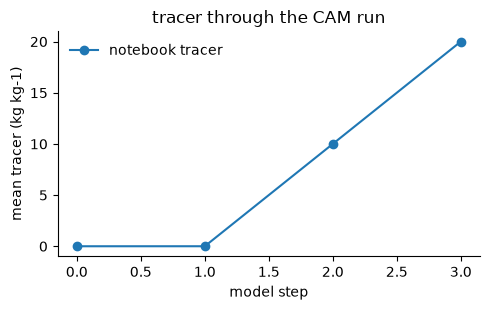

{'name': 'notebook_tracer_source',
 'phase': 'cam_run1',
 'enabled': True,
 'plan': ({'index': 0,
   'phase': 'coupling',
   'name': 'boundary_import',
   'operation': 'boundary_import',
   'kind': 'boundary',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 202,
   'enabled': True},
  {'index': 1,
   'phase': 'cam_run2',
   'name': 'prepare',
   'operation': 'prepare',
   'kind': 'kernel',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 401,
   'enabled': True},
  {'index': 2,
   'phase': 'cam_run2',
   'name': 'surface_fluxes_and_emissions',
   'operation': 'chem_emissions',
   'kind': 'scheme',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 402,
   'enabled': True},
  {'index': 3,
   'phase'

In [8]:
# Track the global-mean tracer against model step. Dynamic fields use the
# same live step-series UI as native CAM fields.
tracer_steps = driver.cam.state.plot_steps(
    'tracer', rank='global', statistic='mean', label='notebook tracer',
)

# Run only this process; the model clock does not advance.
# tracer_process.run()
driver.run(steps=1)
display(tracer_steps)

# Replace the live callback without reinstalling or moving the process.
def revised_tracer(state, context):
    state.tracer += 10.0

tracer_process.reload(revised_tracer)
# tracer_process.run()
driver.run(steps=2)
display(tracer_steps)

# The same object controls its placement and on/off state.
tracer_process.move(before='deep_convection')
tracer_process.disable()
tracer_process.enable()

## 4. Load an original Fortran process at runtime

The same `state.create(...)` interface defines its inputs. Use `like=` to reuse an existing layout or `dims=` when the Fortran interface requires an explicit layout. freeCAM generates the `bind(C)` adapter, compiles the device `.so`, loads it on every rank, and inserts the process into the workflow.

In [9]:
driver.cam.state.create(
    'runtime_temperature',
    dims=('nphys_local', 'pver'),
    units='K',
    initial=240.0,
    standard_name='runtime_plugin_temperature',
)
driver.cam.state.create(
    'runtime_temperature_increment',
    dims=(),
    units='K',
    initial=1.5,
    writable=False,
    standard_name='runtime_plugin_temperature_increment',
)

fortran_process = driver.cam.physics.install_fortran(
    driver.repo / 'examples/plugins/runtime_temperature_offset/device.yaml',
    project_root=driver.repo,
    process='runtime_temperature_offset',
    after='dadadj',
    unsafe=True,
)
fortran_process.run()
driver.cam.state.runtime_temperature.stats(rank='global')

{'rank': 'global', 'count': 414780, 'min': 241.5, 'max': 241.5, 'mean': 241.5}

## 5. Every supported physics interface

`driver.cam.physics` is a flat API: original module/subroutine nesting and CAM phases are implementation metadata, not part of the user path. The 262 former catalog-only interfaces are now runtime-process templates with generated StatePool pointer adapters. The current PI-CAM executable can load 226 of them; the other 36 belong to inactive COSP, CARMA, or legacy-radiation configurations.

In [10]:
physics = driver.cam.physics
display(physics)

# Access by the original Fortran operation or by its readable workflow alias.
dadadj = physics.dadadj
dry_adjustment = physics.dry_adjustment
display(dadadj.run())

# Every source process uses the same flat namespace.
cloud_ice = physics.cloud_fraction_fice
evaporation = physics.zm_conv_evap

# Each process has its own control handle; restore the original state here.
physics.radiation.disable()
physics.radiation.enable()

Python API,Original routine,Level,Parent stage,Capability
surface_fluxes_and_emissions,chem_emissions,stage,—,enabled
tracers_and_chemistry,tracers_chemistry,stage,—,disabled
tracer_tendencies_leaf,leaf_tracers_timestep_tend,leaf,cam_run2.tracers_and_chemistry,enabled
age_of_air_tendencies_leaf,leaf_aoa_tracers_timestep_tend,leaf,cam_run2.tracers_and_chemistry,enabled
chemistry_tendencies_leaf,leaf_chem_timestep_tend,leaf,cam_run2.tracers_and_chemistry,enabled
vertical_diffusion,vertical_diffusion_tend,stage,—,enabled
rayleigh_friction,rayleigh_friction_tend,stage,—,enabled
aerosol_dry_deposition,aero_model_drydep,stage,—,disabled
aerosol_dry_deposition_leaf,leaf_aero_model_drydep,leaf,cam_run2.aerosol_dry_deposition,enabled
carma_aerosol_tendencies_leaf,leaf_carma_timestep_tend,leaf,cam_run2.aerosol_dry_deposition,enabled


{'sequence': 202,
 'coupling_step': 4,
 'model_step': 3,
 'phase': 'direct_kernel',
 'name': 'dadadj',
 'operation': 'dadadj',
 'native_id': None}

{'name': 'radiation',
 'phase': 'cam_run1',
 'enabled': True,
 'plan': ({'index': 0,
   'phase': 'coupling',
   'name': 'boundary_import',
   'operation': 'boundary_import',
   'kind': 'boundary',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 202,
   'enabled': True},
  {'index': 1,
   'phase': 'cam_run2',
   'name': 'prepare',
   'operation': 'prepare',
   'kind': 'kernel',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 401,
   'enabled': True},
  {'index': 2,
   'phase': 'cam_run2',
   'name': 'surface_fluxes_and_emissions',
   'operation': 'chem_emissions',
   'kind': 'scheme',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 402,
   'enabled': True},
  {'index': 3,
   'phase': 'cam_run2',

## 6. Insert an original process into the workflow

For a process loadable in this case, `workflow.insert(...)` automatically binds its original Fortran arguments to the live StatePool and returns `None`, like a Python list. Retrieve the inserted process by name when a control handle is needed.

In [11]:
# Loadable source processes bind their StatePool context automatically.
driver.cam.workflow.insert(
    driver.cam.physics.cloud_fraction_fice,
    after='dry_adjustment',
)
cloud_process = driver.cam.workflow['cloud_fraction_fice']

# Run only this original routine, then show its named StatePool outputs.
cloud_process.run()
display({
    'fice': cloud_process.fice.stats(rank='global'),
    'fsnow': cloud_process.fsnow.stats(rank='global'),
})

# It is now a normal workflow process, not a standalone call.
cloud_process.move(before='radiation')
cloud_process.disable()
cloud_process.enable()
driver.cam.workflow

{'fice': {'rank': 'global',
  'count': 414780,
  'min': 0.0,
  'max': 1.0,
  'mean': 0.5811009408812666},
 'fsnow': {'rank': 'global',
  'count': 414780,
  'min': 0.0,
  'max': 1.0,
  'mean': 0.7317505091987195}}

#,process,implementation
0,surface_fluxes_and_emissions,fortran-numerical-kernel
1,tracers_and_chemistry,fortran-numerical-kernel
2,tracer_tendencies,fortran-numerical-kernel
3,age_of_air_tendencies,fortran-numerical-kernel
4,chemistry_tendencies,fortran-numerical-kernel
5,vertical_diffusion,fortran-numerical-kernel
6,rayleigh_friction,fortran-numerical-kernel
7,aerosol_dry_deposition,fortran-numerical-kernel
8,aerosol_dry_deposition,fortran-numerical-kernel
9,carma_aerosol_tendencies,fortran-numerical-kernel


## 7. Remove runtime extensions and close the model

Processes must be removed before deleting fields they use. `driver.close()` finalizes CAM and releases the persistent PBS/MPI session.

In [12]:
cloud_process.remove()
tracer_process.remove()
fortran_process.remove()
for process in driver.cam.configured_processes:
    process.remove()

del driver.cam.state.rh
del driver.cam.state.tracer
del driver.cam.state.runtime_temperature
del driver.cam.state.runtime_temperature_increment

control_driver.close()
driver.close()

## 8. Browse finalized history output with Xarray

History and restart files stay on the filesystem and are opened lazily after CAM finalizes them. `plot_steps(...)` reduces each saved time record to one diagnostic value, while `open(...)` exposes the complete Xarray dataset. Neither operation copies the distributed live StatePool into the Notebook.

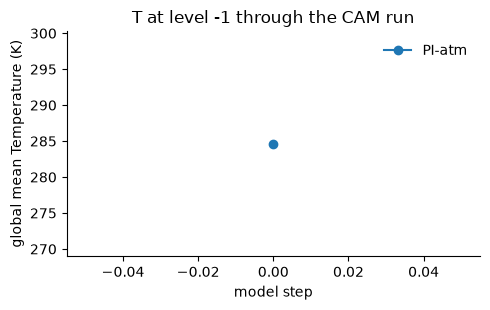

<xarray.Dataset> Size: 137MB
Dimensions:        (lev: 30, ilev: 31, time: 1, ncol: 13826, nbnd: 2)
Coordinates:
  * lev            (lev) float64 240B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev           (ilev) float64 248B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time           (time) object 8B 0001-01-01 00:00:00
Dimensions without coordinates: ncol, nbnd
Data variables: (12/214)
    hyam           (lev) float64 240B ...
    hybm           (lev) float64 240B ...
    P0             float64 8B ...
    hyai           (ilev) float64 248B ...
    hybi           (ilev) float64 248B ...
    date           (time) int32 4B ...
    ...             ...
    pom_a1_SRF     (time, ncol) float32 55kB ...
    so4_a1_SRF     (time, ncol) float32 55kB ...
    so4_a2_SRF     (time, ncol) float32 55kB ...
    so4_a3_SRF     (time, ncol) float32 55kB ...
    soa_a1_SRF     (time, ncol) float32 55kB ...
    soa_a2_SRF     (time, ncol) float32 55kB ...
Attributes:
    np:               4
    ne:               16
    Conventions:      CF-1.0
    source:           CAM
    case:             f.e13.F1850C5.ne16_g16.icesm131_ihesp.PI-cam-oracle.50step
    title:            
    logname:          ruitong
    host:             dec2437
    Version:          $Name$
    revision_Id:      $Id$
    initial_file:     /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/ho...
    topography_file:  /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/US...

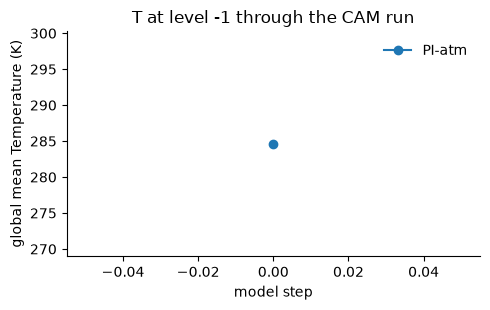

In [13]:
step_axis = driver.cam.history.plot_steps(
    'T', statistic='global_mean', level=-1,
    marker='o', label='PI-atm',
)
display(step_axis.figure)

with driver.cam.history.open('h0') as history:
    display(history)